# Chapter 46 — Growth Comparisons

> **Prerequisites:** ch041 (Exponents and Powers), ch042 (Exponential Growth), ch043 (Logarithms Intuition), ch044 (Logarithmic Scales)  
> **You will learn:**
> - The hierarchy of growth rates: constant < log < polynomial < exponential < factorial
> - Formal asymptotic notation: O, Ω, Θ, and how to use it correctly
> - Why the growth hierarchy matters far more than constant factors for large inputs
> - How to compare two growth rates rigorously using limits
> - Stirling's approximation for factorial growth
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

When an algorithm runs in `O(n²)` time, and a competitor's runs in `O(n log n)`, which is faster? "It depends on the constant factor" — but only for small `n`. For large `n`, the growth rate dominates everything else.

The fundamental growth hierarchy (slowest to fastest):

```
O(1) < O(log n) < O(√n) < O(n) < O(n log n) < O(n²) < O(n³) < O(2ⁿ) < O(n!)
```

Every function in this list eventually dominates all functions to its left — no matter how large the constant factors.

**What this means in practice:**
- A `O(2^n)` algorithm with constant factor 0.0001 is eventually slower than a `O(n^1000)` algorithm with constant factor 10^100.
- Eventually. The crossover point might be at `n = 10^50`, but the hierarchy is strict.

**Why it matters:** Algorithm selection, data structure choice, feasibility analysis, and understanding which mathematical operations are "cheap" vs "expensive" all depend on understanding where operations fall in this hierarchy.

**Common misconception:** O-notation describes *worst-case* behavior in many (but not all) contexts. It also describes average case, best case, or expected case — the notation itself says nothing about which. Always state what case you're analyzing.

---

## 2. Intuition & Mental Models

**Physical analogy:** Think of different growth rates as different transportation modes. Constant time is teleportation — you're already there. Log time is a subway (each station covers 2× the distance). Linear is walking. Polynomial is crawling. Exponential is running backwards.

**Computational analogy:** Think of growth rate as "how does problem difficulty change when you double the input?":
- `O(1)`: no change — sorting a million items takes the same time as sorting 1 if you have a hash table lookup.
- `O(log n)`: adds one step — binary search on 2n items takes 1 step more.
- `O(n)`: doubles — processing 2n items takes 2× as long.
- `O(n²)`: quadruples — 2n items → 4× as long.
- `O(2^n)`: squares — 2(n+1) = 2×2^n, so adding one input doubles the work.

**The limit tool:** To compare `f(n)` vs `g(n)`, compute `lim_{n→∞} f(n)/g(n)`:
- Result = 0: `f` grows slower than `g` (`f = o(g)`)
- Result = c > 0 (finite): same growth rate (`f = Θ(g)`)
- Result = ∞: `f` grows faster than `g`

**Recall from ch042:** Exponential growth overtakes any polynomial *(from ch042 — Exponential Growth)*. The ratio `2^n / n^k → ∞` for any fixed `k`.

---

## 3. Visualization

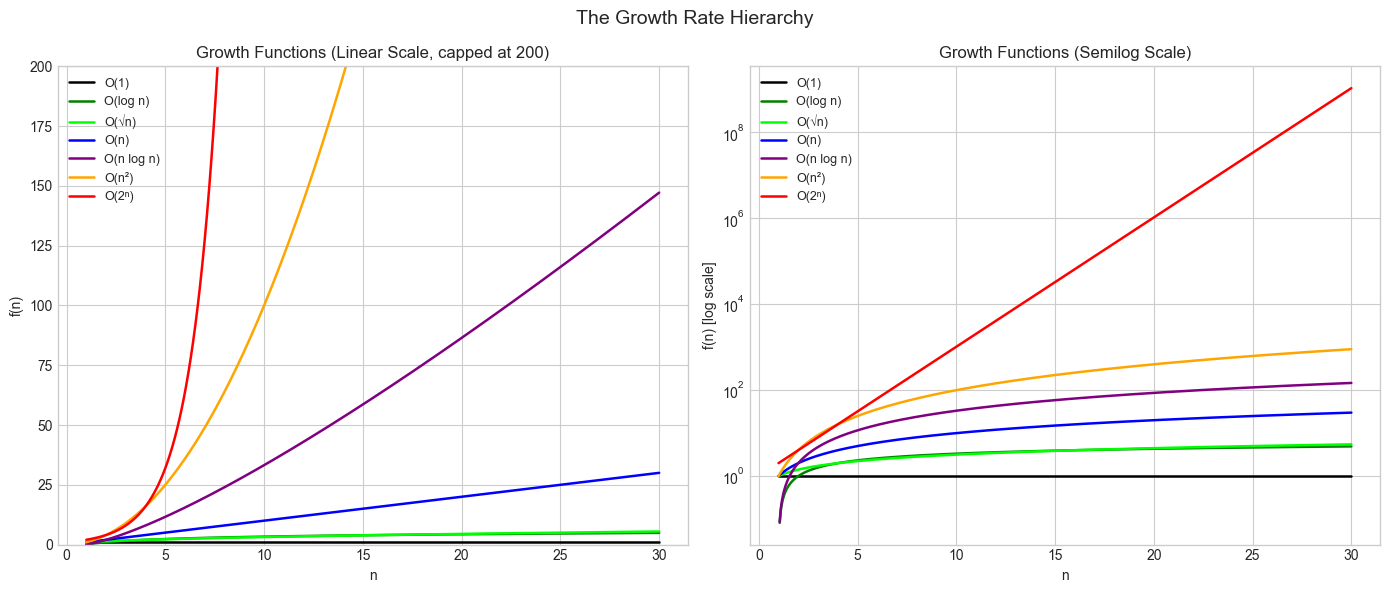

In [1]:
# --- Visualization: The growth hierarchy ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

n = np.linspace(1, 30, 500)

growth_functions = [
    ('O(1)',      np.ones_like(n),               'black'),
    ('O(log n)',  np.log2(n),                     'green'),
    ('O(√n)',     np.sqrt(n),                     'lime'),
    ('O(n)',      n,                              'blue'),
    ('O(n log n)', n * np.log2(n),               'purple'),
    ('O(n²)',     n**2,                           'orange'),
    ('O(2ⁿ)',     2**n,                           'red'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for label, f, color in growth_functions:
    axes[0].plot(n, f, label=label, color=color, linewidth=1.8)
    safe = f[f > 0]
    n_safe = n[f > 0]
    axes[1].semilogy(n_safe, safe, label=label, color=color, linewidth=1.8)

axes[0].set_ylim(0, 200)
axes[0].set_title('Growth Functions (Linear Scale, capped at 200)')
axes[0].set_xlabel('n')
axes[0].set_ylabel('f(n)')
axes[0].legend(fontsize=9)

axes[1].set_title('Growth Functions (Semilog Scale)')
axes[1].set_xlabel('n')
axes[1].set_ylabel('f(n) [log scale]')
axes[1].legend(fontsize=9)

plt.suptitle('The Growth Rate Hierarchy', fontsize=14)
plt.tight_layout()
plt.show()

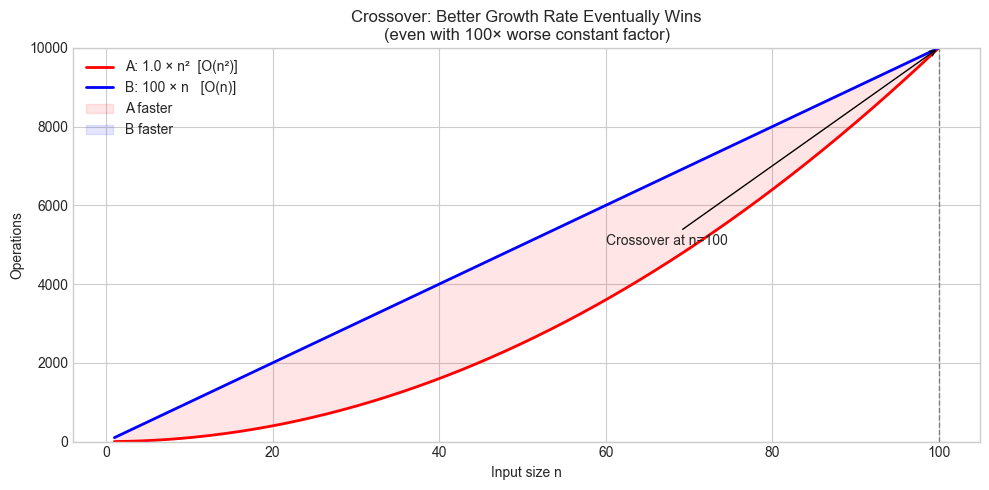

In [2]:
# --- Visualization: Crossover points — when does faster eventually win? ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Case: Algorithm A (fast constant, worse complexity) vs Algorithm B (slow constant, better complexity)
n = np.linspace(1, 100, 500)

A_const, A_growth = 1.0, lambda n: n**2      # O(n²)
B_const, B_growth = 100.0, lambda n: n       # O(n), but 100× slower constant

f_A = A_const * A_growth(n)
f_B = B_const * B_growth(n)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n, f_A, label='A: 1.0 × n²  [O(n²)]',  color='red',  linewidth=2)
ax.plot(n, f_B, label='B: 100 × n   [O(n)]',    color='blue', linewidth=2)

# Find crossover: f_A = f_B → n² = 100n → n = 100
crossover = 100
ax.axvline(crossover, color='gray', linestyle='--', linewidth=1)
ax.annotate(f'Crossover at n={crossover}', (crossover, f_A[np.argmin(np.abs(n-crossover))]),
            xytext=(60, 5000), fontsize=10, arrowprops=dict(arrowstyle='->'))

ax.fill_between(n, f_A, f_B, where=f_A < f_B, alpha=0.1, color='red',  label='A faster')
ax.fill_between(n, f_A, f_B, where=f_A >= f_B, alpha=0.1, color='blue', label='B faster')

ax.set_title('Crossover: Better Growth Rate Eventually Wins\n(even with 100× worse constant factor)')
ax.set_xlabel('Input size n')
ax.set_ylabel('Operations')
ax.legend()
ax.set_ylim(0, 10000)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

### Asymptotic notation

```
f(n) = O(g(n)):  there exist C > 0, n₀ > 0 such that f(n) ≤ C·g(n) for all n > n₀
                 "f is eventually bounded above by a constant multiple of g"

f(n) = Ω(g(n)):  there exist C > 0, n₀ > 0 such that f(n) ≥ C·g(n) for all n > n₀
                 "f grows at least as fast as g"

f(n) = Θ(g(n)):  f = O(g) AND f = Ω(g)
                 "f and g grow at the same rate (same order)"

f(n) = o(g(n)):  lim_{n→∞} f(n)/g(n) = 0
                 "f grows strictly slower than g"
```

### The limit comparison

```
lim_{n→∞} f(n)/g(n) = 0   →  f = o(g)    (f grows slower)
lim_{n→∞} f(n)/g(n) = L>0 →  f = Θ(g)   (same rate)
lim_{n→∞} f(n)/g(n) = ∞   →  f = ω(g)   (f grows faster)
```

### Stirling's approximation

Factorial growth is faster than exponential:

```
n! ≈ √(2πn) × (n/e)^n

ln(n!) ≈ n·ln(n) - n + (1/2)·ln(2πn)
```

This shows `n!` grows faster than `a^n` for any base `a` — the exponent in `(n/e)^n` itself grows with `n`.

### Key limit results to know

```
lim n^k / a^n = 0     for any k, a > 1     (exponential beats polynomial)
lim (log n)^k / n = 0 for any k > 0        (polynomial beats any power of log)
lim a^n / n! = 0      for any a             (factorial beats exponential)
```

In [3]:
# --- Verify limit claims numerically ---
import numpy as np

print("Limit verification: ratios as n → ∞")
print("\n1. n^k / 2^n → 0  (exponential beats polynomial)")
for k in [2, 5, 10]:
    ratios = [(n, n**k / 2**n) for n in [10, 50, 100, 200]]
    row = "   " + "  ".join(f"n={n}: {r:.2e}" for n, r in ratios)
    print(f"  k={k:2d}: {row}")

print("\n2. (log n)^k / n → 0  (n beats any power of log n)")
for k in [1, 2, 5]:
    ratios = [(n, np.log(n)**k / n) for n in [100, 10_000, 1_000_000]]
    row = "   " + "  ".join(f"n={n:.0e}: {r:.2e}" for n, r in ratios)
    print(f"  k={k}: {row}")

print("\n3. 2^n / n! → 0  (factorial beats exponential)")
import math
for n in [5, 10, 20, 30, 40]:
    r = 2**n / math.factorial(n)
    print(f"  n={n:2d}: 2^n / n! = {r:.4e}")

Limit verification: ratios as n → ∞

1. n^k / 2^n → 0  (exponential beats polynomial)
  k= 2:    n=10: 9.77e-02  n=50: 2.22e-12  n=100: 7.89e-27  n=200: 2.49e-56
  k= 5:    n=10: 9.77e+01  n=50: 2.78e-07  n=100: 7.89e-21  n=200: 1.99e-49
  k=10:    n=10: 9.77e+06  n=50: 8.67e+01  n=100: 7.89e-11  n=200: 6.37e-38

2. (log n)^k / n → 0  (n beats any power of log n)
  k=1:    n=1e+02: 4.61e-02  n=1e+04: 9.21e-04  n=1e+06: 1.38e-05
  k=2:    n=1e+02: 2.12e-01  n=1e+04: 8.48e-03  n=1e+06: 1.91e-04
  k=5:    n=1e+02: 2.07e+01  n=1e+04: 6.63e+00  n=1e+06: 5.03e-01

3. 2^n / n! → 0  (factorial beats exponential)
  n= 5: 2^n / n! = 2.6667e-01
  n=10: 2^n / n! = 2.8219e-04
  n=20: 2^n / n! = 4.3100e-13
  n=30: 2^n / n! = 4.0480e-24
  n=40: 2^n / n! = 1.3476e-36


---

## 5. Python Implementation

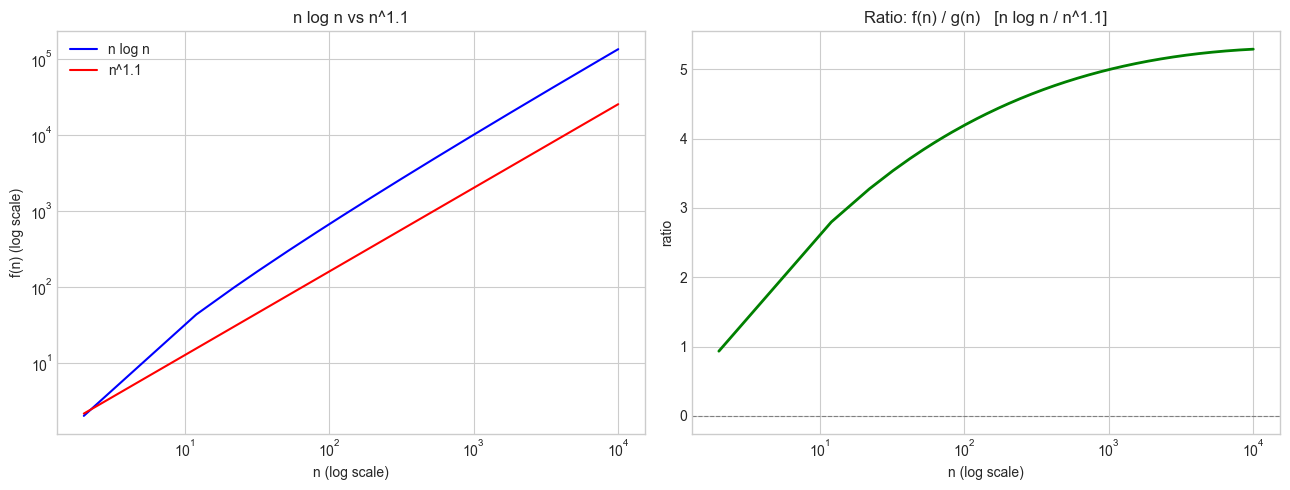

Ratio at n=10000: 5.289934
  → n log n = Θ(n^1.1)  (same order)


In [4]:
# --- Implementation: Growth rate comparison tool ---
import numpy as np
import math
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def compare_growth_rates(f, g, f_label, g_label, n_values=None):
    """
    Compare two growth functions f(n) and g(n) by computing their ratio.

    If ratio → 0:   f is o(g) — f grows slower
    If ratio → L>0: f is Θ(g) — same order
    If ratio → ∞:   f is ω(g) — f grows faster

    Args:
        f, g:         callables taking a numpy array
        f_label, g_label: names for display
        n_values:     array of n values to evaluate

    Returns:
        Ratio array f(n)/g(n)
    """
    if n_values is None:
        n_values = np.logspace(0, 4, 400)

    f_vals = f(n_values)
    g_vals = g(n_values)

    # Avoid division by zero
    ratio = np.where(g_vals > 0, f_vals / g_vals, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.loglog(n_values, f_vals, label=f_label, color='blue')
    ax.loglog(n_values, g_vals, label=g_label, color='red')
    ax.set_title(f'{f_label} vs {g_label}')
    ax.set_xlabel('n (log scale)')
    ax.set_ylabel('f(n) (log scale)')
    ax.legend()

    ax = axes[1]
    finite = np.isfinite(ratio) & (ratio > 0)
    ax.semilogx(n_values[finite], ratio[finite], color='green', linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'Ratio: f(n) / g(n)   [{f_label} / {g_label}]')
    ax.set_xlabel('n (log scale)')
    ax.set_ylabel('ratio')

    plt.tight_layout()
    plt.show()

    # Report the ratio at the largest n
    last_ratio = ratio[finite][-1] if finite.any() else float('nan')
    print(f"Ratio at n={n_values[finite][-1]:.0f}: {last_ratio:.6f}")
    if last_ratio < 0.01:
        print(f"  → {f_label} = o({g_label})  (f grows slower)")
    elif last_ratio > 100:
        print(f"  → {f_label} = ω({g_label})  (f grows faster)")
    else:
        print(f"  → {f_label} = Θ({g_label})  (same order)")

    return ratio


# Example: n log n vs n^1.1 — which grows faster?
n_vals = np.linspace(2, 10_000, 1000)
ratio = compare_growth_rates(
    f=lambda n: n * np.log2(n),
    g=lambda n: n**1.1,
    f_label='n log n',
    g_label='n^1.1',
    n_values=n_vals
)

---

## 6. Experiments

In [5]:
# --- Experiment 1: Stirling's approximation accuracy ---
# Hypothesis: Stirling's approximation becomes extremely accurate as n grows.
# The relative error decreases as 1/(12n).
# Try changing: MAX_N

import numpy as np
import math

MAX_N = 30  # <-- modify this (try 50, 100)

print(f"Stirling's approximation: n! ≈ √(2πn) × (n/e)^n")
print(f"{'n':>5} {'n!':>20} {'Stirling':>20} {'rel error':>12}")
print("-" * 62)

for n in range(1, MAX_N + 1):
    exact    = float(math.factorial(n))
    stirling = math.sqrt(2 * math.pi * n) * (n / math.e) ** n
    rel_err  = abs(exact - stirling) / exact
    if n <= 10 or n % 5 == 0:
        print(f"{n:>5} {exact:>20.4e} {stirling:>20.4e} {rel_err:>12.4e}")

Stirling's approximation: n! ≈ √(2πn) × (n/e)^n
    n                   n!             Stirling    rel error
--------------------------------------------------------------
    1           1.0000e+00           9.2214e-01   7.7863e-02
    2           2.0000e+00           1.9190e+00   4.0498e-02
    3           6.0000e+00           5.8362e+00   2.7298e-02
    4           2.4000e+01           2.3506e+01   2.0576e-02
    5           1.2000e+02           1.1802e+02   1.6507e-02
    6           7.2000e+02           7.1008e+02   1.3780e-02
    7           5.0400e+03           4.9804e+03   1.1826e-02
    8           4.0320e+04           3.9902e+04   1.0357e-02
    9           3.6288e+05           3.5954e+05   9.2128e-03
   10           3.6288e+06           3.5987e+06   8.2960e-03
   15           1.3077e+12           1.3004e+12   5.5393e-03
   20           2.4329e+18           2.4228e+18   4.1577e-03
   25           1.5511e+25           1.5460e+25   3.3276e-03
   30           2.6525e+32         

C:\Users\user\AppData\Local\Temp\ipykernel_13996\3775643615.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


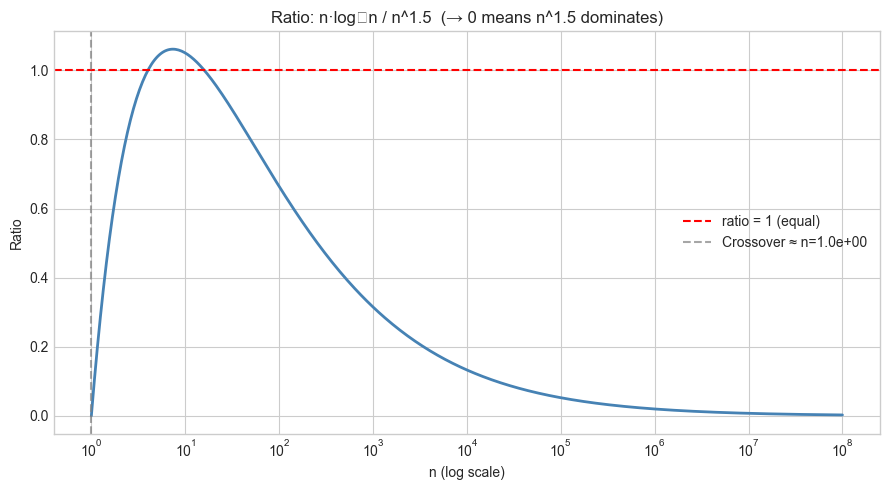

n·log n is larger than n^1.5 until approximately n = 1.00e+00
For n > 1.00e+00: n^1.5 = ω(n log n)


In [6]:
# --- Experiment 2: n log n vs n^1.5 — a counterintuitive crossover ---
# Hypothesis: n^1.5 eventually dominates n log n because 1.5 > 1.
# But the crossover requires very large n.
# Try changing: EXPONENT to find when crossover happens

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

EXPONENT = 1.5   # <-- modify this (try 1.1, 1.2, 2.0)

n = np.logspace(0, 8, 500)  # 1 to 10^8

f = n * np.log2(np.maximum(n, 1))
g = n ** EXPONENT

ratio = f / g

# Find approximate crossover
crossover_idx = np.argwhere(ratio < 1)
crossover_n = n[crossover_idx[0][0]] if len(crossover_idx) > 0 else None

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(n, ratio, color='steelblue', linewidth=2)
ax.axhline(1, color='red', linestyle='--', label='ratio = 1 (equal)')
if crossover_n:
    ax.axvline(crossover_n, color='gray', linestyle='--', alpha=0.7,
               label=f'Crossover ≈ n={crossover_n:.1e}')
ax.set_title(f'Ratio: n·log₂n / n^{EXPONENT}  (→ 0 means n^{EXPONENT} dominates)')
ax.set_xlabel('n (log scale)')
ax.set_ylabel('Ratio')
ax.legend()
plt.tight_layout()
plt.show()

if crossover_n:
    print(f"n·log n is larger than n^{EXPONENT} until approximately n = {crossover_n:.2e}")
    print(f"For n > {crossover_n:.2e}: n^{EXPONENT} = ω(n log n)")

In [7]:
# --- Experiment 3: Practical threshold — when does algorithm complexity matter? ---
# Hypothesis: For n > some threshold, the growth rate determines feasibility
# regardless of hardware speed.
# Change OPS_PER_SEC to see how much better hardware helps.

import numpy as np

OPS_PER_SEC = 1e12    # <-- modify this (1e9=laptop, 1e12=fast workstation, 1e15=cluster)
TIME_LIMIT_SEC = 1.0  # <-- modify this (try 3600 for one hour, 86400 for one day)

def max_n_for(complexity_fn, ops, time_limit, max_n=10000):
    """Find maximum n where complexity_fn(n) / ops <= time_limit."""
    for n in range(1, max_n + 1):
        try:
            if complexity_fn(n) / ops > time_limit:
                return n - 1
        except (OverflowError, ValueError):
            return n - 1
    return max_n

import math
complexities = [
    ('O(log n)',   lambda n: math.log2(max(n, 1))),
    ('O(n)',       lambda n: n),
    ('O(n log n)', lambda n: n * math.log2(max(n, 1))),
    ('O(n²)',      lambda n: n**2),
    ('O(n³)',      lambda n: n**3),
    ('O(2^n)',     lambda n: 2.0**n),
    ('O(n!)',      lambda n: float(math.factorial(n)) if n <= 20 else float('inf')),
]

print(f"Maximum feasible input size n (ops={OPS_PER_SEC:.0e}/s, time={TIME_LIMIT_SEC}s)")
print("-" * 50)
for name, fn in complexities:
    n_max = max_n_for(fn, OPS_PER_SEC, TIME_LIMIT_SEC)
    print(f"  {name:15s}: n_max ≈ {n_max}")

Maximum feasible input size n (ops=1e+12/s, time=1.0s)
--------------------------------------------------
  O(log n)       : n_max ≈ 10000
  O(n)           : n_max ≈ 10000
  O(n log n)     : n_max ≈ 10000
  O(n²)          : n_max ≈ 10000
  O(n³)          : n_max ≈ 10000
  O(2^n)         : n_max ≈ 39
  O(n!)          : n_max ≈ 14


---

## 7. Exercises

**Easy 1.** Rank these functions in order of growth (slowest to fastest): `n³`, `3^n`, `n!`, `n log n`, `√n`, `log(log n)`, `n^0.01`. Verify numerically for `n = 100`.

**Easy 2.** Prove (using the limit definition) that `5n² + 3n + 7 = Θ(n²)`. Identify the constants `C₁`, `C₂`, and `n₀` such that `C₁n² ≤ 5n² + 3n + 7 ≤ C₂n²` for all `n > n₀`.

**Medium 1.** Plot `n!` and Stirling's approximation on a log scale for `n = 1..50`. On the same plot, add `2^n` and `n^n`. Verify the hierarchy `2^n < n! < n^n` numerically.

**Medium 2.** You have two sorting algorithms: A runs in `5n log n` operations; B runs in `0.001 n²`. For what value of `n` does B become slower than A? Solve analytically and verify numerically.

**Hard.** Prove that `n^k = o(a^n)` for any `k > 0` and `a > 1` using L'Hôpital's rule *(you may use the rule without formal proof: if `lim f(n)/g(n)` is ∞/∞, it equals `lim f'(n)/g'(n)`)*. How many applications of L'Hôpital does it take?

---

## 8. Mini Project: Empirical Complexity Measurement

In [ ]:
# --- Mini Project: Recovering complexity from timing data ---
#
# Problem:
#   Given a black-box function, determine its asymptotic complexity
#   by measuring its runtime at different input sizes and fitting
#   a growth model.
#
# Method:
#   1. Time the function at input sizes n₁, n₂, ..., nₖ
#   2. Plot time vs n on log-log axes
#   3. The slope of the log-log line gives the exponent of the polynomial
#   4. If the log-log plot curves (not straight), suspect exponential or factorial

import numpy as np
import time
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Three black-box algorithms (complexity hidden)
def algo_A(n):
    """Unknown complexity — just benchmark it."""
    total = 0
    for i in range(n):
        for j in range(n):
            total += i + j
    return total

def algo_B(n):
    """Unknown complexity."""
    arr = list(range(n))
    for _ in range(int(n * np.log2(max(n, 2)))):
        arr[n // 2] += 1
    return sum(arr)

def algo_C(n):
    """Unknown complexity."""
    total = 0
    for i in range(n):
        total += i
    return total


def measure_timing(algo, sizes, repeats=3):
    """Time an algorithm at multiple input sizes."""
    times = []
    for n in sizes:
        runs = []
        for _ in range(repeats):
            start = time.perf_counter()
            algo(n)
            runs.append(time.perf_counter() - start)
        times.append(min(runs))  # take minimum (less noise)
    return np.array(times)


sizes = [50, 100, 150, 200, 300, 400, 500]

print("Measuring timing...")
t_A = measure_timing(algo_A, sizes)
t_B = measure_timing(algo_B, sizes)
t_C = measure_timing(algo_C, sizes)
print("Done.")

# Fit log-log slope: log(t) = slope × log(n) + const → t = C × n^slope
def fit_complexity_exponent(n_arr, t_arr):
    slope, _ = np.polyfit(np.log(n_arr), np.log(t_arr), 1)
    return slope

n_arr = np.array(sizes)
exp_A = fit_complexity_exponent(n_arr, t_A)
exp_B = fit_complexity_exponent(n_arr, t_B)
exp_C = fit_complexity_exponent(n_arr, t_C)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(n_arr, t_A, 'o-', label=f'Algo A (estimated exponent ≈ {exp_A:.2f})', color='red')
ax.loglog(n_arr, t_B, 's-', label=f'Algo B (estimated exponent ≈ {exp_B:.2f})', color='blue')
ax.loglog(n_arr, t_C, '^-', label=f'Algo C (estimated exponent ≈ {exp_C:.2f})', color='green')
ax.set_title('Empirical Complexity Measurement (Log-Log Plot)')
ax.set_xlabel('Input size n (log scale)')
ax.set_ylabel('Time (s) (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nEmpirical exponents:")
print(f"  Algo A: n^{exp_A:.2f}  → {'O(n²)?' if abs(exp_A-2)<0.3 else 'examine further'}")
print(f"  Algo B: n^{exp_B:.2f}  → {'O(n log n)?' if 1.0 < exp_B < 1.3 else 'examine further'}")
print(f"  Algo C: n^{exp_C:.2f}  → {'O(n)?' if abs(exp_C-1)<0.2 else 'examine further'}")

---

## 9. Chapter Summary & Connections

- The growth hierarchy `O(1) < O(log n) < O(n) < O(n log n) < O(n²) < O(2ⁿ) < O(n!)` is strict: every entry eventually dominates all entries to its left, regardless of constant factors.
- O, Ω, Θ notation provides the vocabulary to state growth comparisons precisely. The limit test `lim f/g` identifies the relationship cleanly.
- Stirling's approximation `n! ≈ √(2πn)(n/e)^n` shows that factorial growth has an exponent that itself grows — placing it above any fixed exponential.
- Empirical complexity measurement via log-log slope fitting is a practical tool for characterizing black-box algorithms.

**Backward connection:** This chapter synthesizes the growth behavior from ch042 (Exponential Growth), the scale intuition from ch044 (Logarithmic Scales), and the exponent arithmetic from ch041 (Exponents and Powers) into a single comparative framework.

**Forward connections:**
- ch047 (Orders of Magnitude) applies this hierarchy to physical and computational scale — connecting growth rates to real measurements.
- The asymptotic notation introduced here is used throughout Part VI (Linear Algebra) to analyze matrix multiplication cost — `O(n³)` naive vs `O(n^{2.37})` for Strassen-type algorithms.
- The factorial count of permutations connects to ch253 (Probability Rules) — `n!` is the number of ways to arrange `n` items, the foundation of combinatorics.

**Going deeper:** *Introduction to Algorithms* (CLRS), Chapter 3 — the standard reference for asymptotic notation. The appendix contains the full proof that `n^k = o(a^n)` for `a > 1`.